In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_excel('D:/数据分析练手/customers.xlsx')
print(df.columns)

Index(['customer_id', 'country', 'age', 'gender', 'membership_tier',
       'registration_to_now_date', 'registration_date', 'total_orders',
       'total_spend_usd', 'avg_order_value_usd', 'days_since_last_purchase',
       'preferred_category', 'preferred_device', 'preferred_payment_method',
       'acquisition_channel', 'reviews_given', 'avg_review_score',
       'return_rate', 'returns_made', 'wishlist_items',
       'newsletter_subscribed', 'churned', 'age_group', 'registration_year',
       'monthly_orders', 'monthly_spend'],
      dtype='object')


In [3]:
features = df[['days_since_last_purchase','monthly_orders','monthly_spend']]

In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [5]:
inertia = []
for k in range(1,10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)
print(inertia)

[23990.999999999996, 18882.992529611613, 10358.747886012738, 7866.52987729987, 6856.780845051468, 6242.97299141839, 5005.193229811682, 4534.978117883905, 4255.008728399954]


In [6]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

In [7]:
cluster_profile = df.groupby('cluster').agg({
    'days_since_last_purchase':'mean',
    'monthly_orders':'mean',
    'monthly_spend':'mean',
    'customer_id':'count'}).round(2)
print(cluster_profile)

         days_since_last_purchase  monthly_orders  monthly_spend  customer_id
cluster                                                                      
0                          154.97            1.38         117.21         1562
1                           34.58            1.18          96.72         5685
2                           49.24            9.50         899.19          642
3                           58.14           26.13        3289.41          108


In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

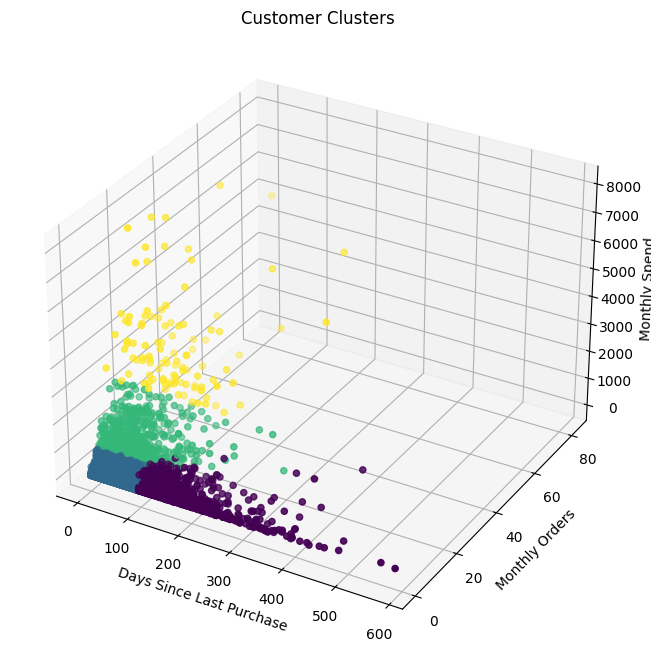

In [9]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df['days_since_last_purchase'],
    df['monthly_orders'],
    df['monthly_spend'],
    c=df['cluster'])
ax.set_xlabel('Days Since Last Purchase')
ax.set_ylabel('Monthly Orders')
ax.set_zlabel('Monthly Spend')
plt.title('Customer Clusters')
plt.show()

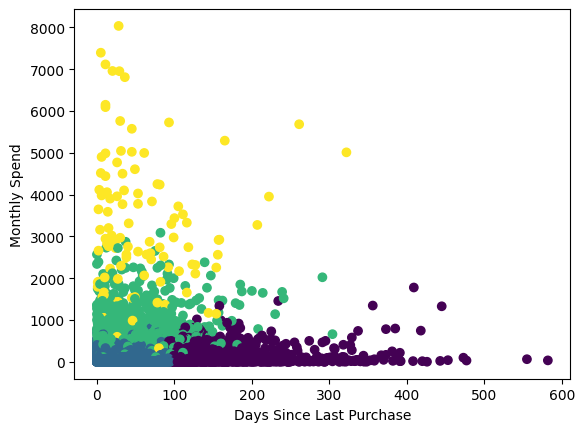

In [10]:
plt.scatter(
    df['days_since_last_purchase'],
    df['monthly_spend'],
    c=df['cluster']
)

plt.xlabel('Days Since Last Purchase')
plt.ylabel('Monthly Spend')
plt.show()

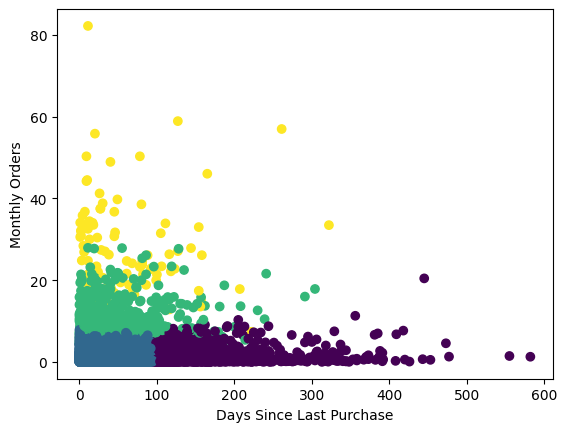

In [11]:
plt.scatter(
    df['days_since_last_purchase'],
    df['monthly_orders'],
    c=df['cluster'])
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Monthly Orders')
plt.show()

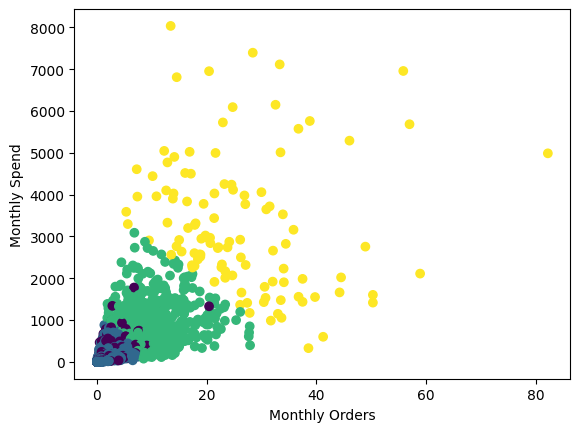

In [12]:
plt.scatter(
    df['monthly_orders'],
    df['monthly_spend'],
    c=df['cluster'])
plt.xlabel('Monthly Orders')
plt.ylabel('Monthly Spend')
plt.show()

In [13]:
df['membership_tier'] = pd.Categorical(
    df['membership_tier'],
    categories=['Free', 'Silver', 'Gold','Platinum'],
    ordered=False)
df['acquisition_channel'] = pd.Categorical(
    df['acquisition_channel'],
    categories=['Direct','Email Campaign','Organic Search', 'Paid Ad', 'Referral','Social Media'],
    ordered=False)
df['preferred_device'] = pd.Categorical(
    df['preferred_device'],
    categories=['Mobile', 'Desktop', 'Tablet'],
    ordered=False)

In [14]:
X = df[[
'days_since_last_purchase',
'monthly_orders',
'monthly_spend',
'avg_review_score',
'return_rate',
'membership_tier',
'registration_to_now_date',
'wishlist_items',
'newsletter_subscribed',
'acquisition_channel',
'preferred_device']]

In [15]:
X = pd.get_dummies(
    X,
    columns=[
        'membership_tier',
        'acquisition_channel',
        'preferred_device'
    ],
    drop_first=True)
y = df['churned']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [17]:
scaler1 = StandardScaler()
X_train_scaled = scaler1.fit_transform(X_train)
X_test_scaled = scaler1.transform(X_test)

In [18]:
model = LogisticRegression(max_iter=5000,class_weight = 'balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.64      0.76      1460
           1       0.13      0.57      0.21       140

    accuracy                           0.63      1600
   macro avg       0.54      0.60      0.49      1600
weighted avg       0.87      0.63      0.71      1600



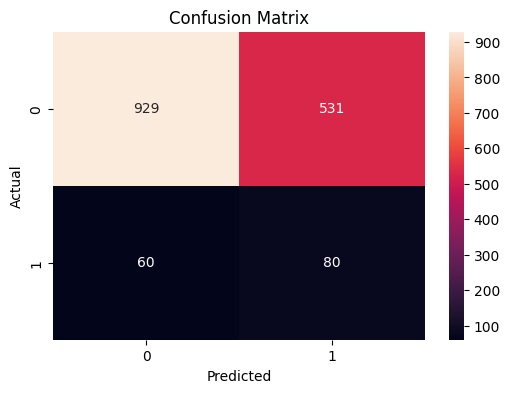

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

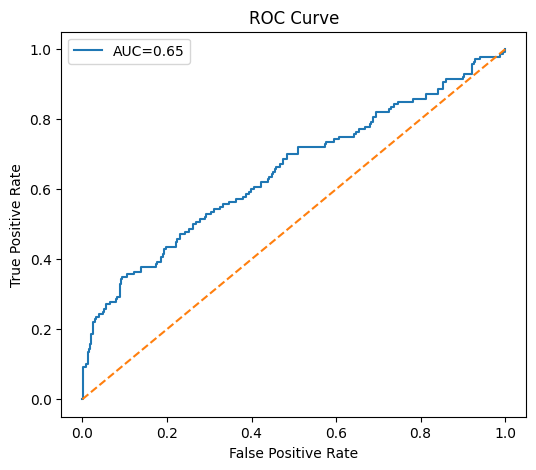

In [21]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={roc_auc:.2f}')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [22]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]})
print(coef_df.sort_values('coef', ascending=False))

                               feature      coef
0             days_since_last_purchase  0.417582
13         acquisition_channel_Paid Ad  0.072197
5             registration_to_now_date  0.056711
7                newsletter_subscribed  0.056353
2                        monthly_spend  0.031919
15    acquisition_channel_Social Media  0.026479
14        acquisition_channel_Referral  0.025991
9                 membership_tier_Gold  0.007906
12  acquisition_channel_Organic Search  0.005702
6                       wishlist_items  0.004811
11  acquisition_channel_Email Campaign -0.006343
16            preferred_device_Desktop -0.008871
17             preferred_device_Tablet -0.068249
3                     avg_review_score -0.090450
10            membership_tier_Platinum -0.107362
1                       monthly_orders -0.156952
8               membership_tier_Silver -0.157018
4                          return_rate -0.293805


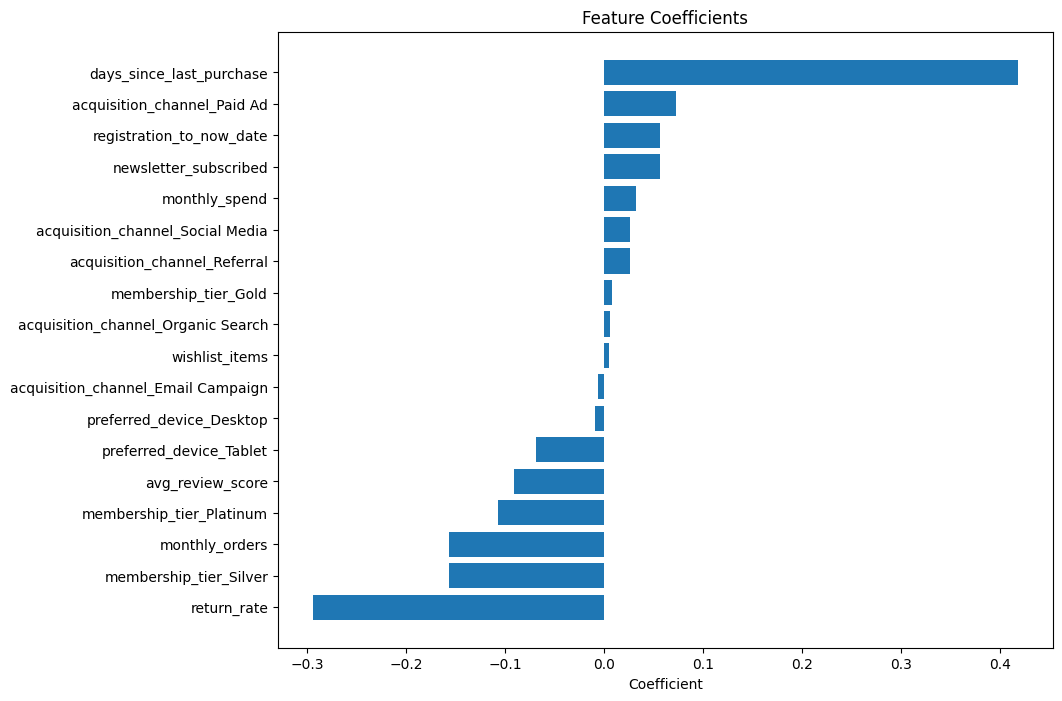

In [23]:
coef_df = coef_df.sort_values('coef')

plt.figure(figsize=(10,8))
plt.barh(coef_df['feature'], coef_df['coef'])
plt.title('Feature Coefficients')
plt.xlabel('Coefficient')
plt.show()